# SDG 3 Multi-Label Text Classification

This notebook implements a complete, reproducible pipeline for classifying text documents
according to the indicators of **Sustainable Development Goal 3 (SDG 3)**.

A single document may be relevant to zero, one, or multiple SDG 3 indicators — making this
a **multi-label classification** problem.

**Primary evaluation metric:** Hamming Loss (lower is better).  
**Secondary metrics:** Micro/Macro F1, Precision, Recall.

### Notebook structure
1. Environment setup
2. Data loading and schema inspection
3. Exploratory data analysis (EDA)
4. Preprocessing pipeline
5. Feature engineering (multiple representations)
6. Experiments (6–10 distinct runs)
7. Results comparison and visualisation
8. Final inference on the test set

---
## 1. Environment Setup

Install all required packages. When running on Google Colab the cell below handles
everything; on a local machine the same command works inside a virtual environment.

After installation the runtime is restarted automatically on Colab — re-run from
this cell onward if that happens.

In [7]:
# Install dependencies not pre-installed on Google Colab.
# We avoid pinning numpy, pandas, scikit-learn, and other packages that Colab
# already provides at compatible versions to prevent binary incompatibility errors.
!pip install -q \
    sentence-transformers \
    gensim \
    nltk \
    beautifulsoup4 \
    lxml

In [8]:
# Download NLTK resources used during preprocessing.
# 'punkt' provides sentence/word tokenisation; 'stopwords' provides the English
# stopword list; 'wordnet' is used by the lemmatiser.
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [9]:
# Standard library and third-party imports used throughout the notebook.
import os
import re
import warnings
import random
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score, classification_report
)
from sklearn.pipeline import Pipeline

import joblib
from tqdm import tqdm

warnings.filterwarnings('ignore')

In [10]:
# Fix random seeds globally so that every run of this notebook produces
# identical results.  All stochastic components (train/val split, model
# initialisations) must also receive this seed individually — see later cells.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    DATA_DIR      = Path('/content/data')
    ARTIFACTS_DIR = Path('/content/artifacts')
else:
    NOTEBOOK_DIR  = Path(os.getcwd())
    DATA_DIR      = NOTEBOOK_DIR.parent / 'data'
    ARTIFACTS_DIR = NOTEBOOK_DIR.parent / 'artifacts'

ARTIFACTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'Devex_train.csv'
TEST_PATH  = DATA_DIR / 'Devex_test_questions.csv'

print('Running on Colab :', ON_COLAB)
print('Data directory   :', DATA_DIR)
print('Artifacts dir    :', ARTIFACTS_DIR)
print('Train file exists:', TRAIN_PATH.exists())
print('Test file exists :', TEST_PATH.exists())


Running on Colab : True
Data directory   : /content/data
Artifacts dir    : /content/artifacts
Train file exists: True
Test file exists : True


---
## 2. Data Loading and Schema Inspection

Both CSVs use latin-1 encoding (UTF-8 raises a codec error on certain characters
present in the raw HTML content).  We derive all column names and label structure
directly from the files rather than assuming any schema.

In [11]:
train_raw = pd.read_csv(TRAIN_PATH, encoding='latin-1')
test_raw  = pd.read_csv(TEST_PATH,  encoding='latin-1')

print('Train shape:', train_raw.shape)
print('Test shape :', test_raw.shape)
print()
print('Train columns and dtypes:')
print(train_raw.dtypes)
print()
print('Test columns and dtypes:')
print(test_raw.dtypes)

Train shape: (2995, 15)
Test shape : (998, 3)

Train columns and dtypes:
Unique ID      int64
Type          object
Text          object
Label 1       object
Label 2       object
Label 3       object
Label 4       object
Label 5       object
Label 6       object
Label 7       object
Label 8       object
Label 9       object
Label 10      object
Label 11     float64
Label 12     float64
dtype: object

Test columns and dtypes:
Unique ID     int64
Type         object
Text         object
dtype: object


In [12]:
# Identify label columns by convention: they all start with 'Label'.
# We also drop Label 11 and Label 12 which are fully empty (confirmed during
# initial inspection — zero non-null values in both columns).
ALL_LABEL_COLS = [c for c in train_raw.columns if c.startswith('Label')]

# Keep only columns that have at least one non-null value.
LABEL_COLS = [c for c in ALL_LABEL_COLS if train_raw[c].notna().any()]

print('All label columns found   :', ALL_LABEL_COLS)
print('Active label columns kept :', LABEL_COLS)
print('Dropped (fully empty)     :', set(ALL_LABEL_COLS) - set(LABEL_COLS))

All label columns found   : ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
Active label columns kept : ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10']
Dropped (fully empty)     : {'Label 11', 'Label 12'}


In [13]:
# Collect the set of unique indicator strings across every active label column.
# This gives us the complete label vocabulary before binarisation.
all_indicator_series = pd.concat(
    [train_raw[c].dropna() for c in LABEL_COLS], ignore_index=True
)
INDICATOR_VOCAB = sorted(all_indicator_series.unique())

print(f'Total unique SDG 3 indicators: {len(INDICATOR_VOCAB)}')
print()
for ind in INDICATOR_VOCAB:
    print(' -', ind)

Total unique SDG 3 indicators: 27

 - 3.1.1 - Maternal mortality ratio
 - 3.1.2 - Proportion of births attended by skilled health personnel
 - 3.2.1 - Under-5 mortality rate
 - 3.2.2 - Neonatal mortality rate
 - 3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations
 - 3.3.2 - Tuberculosis incidence per 100,000 population
 - 3.3.3 - Malaria incidence per 1,000 population
 - 3.3.4 - Hepatitis B incidence per 100,000 population
 - 3.3.5 - Number of people requiring interventions against neglected tropical diseases
 - 3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease
 - 3.4.2 - Suicide mortality rate
 - 3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders
 - 3.5.2 - Harmful use of alcohol, defined according to the national context as alcohol per capita consumption (aged 15 years and older) wit

In [14]:
# Build the multi-label target matrix.
# Each row is converted from a list of indicator strings (spread across Label 1..10)
# into a binary vector of length 27 using MultiLabelBinarizer.
# NaN values are excluded when building each row's label set.

def extract_label_list(row, label_cols):
    """Return the list of non-null indicator strings for a single row."""
    return [row[c] for c in label_cols if pd.notna(row[c])]

train_raw['label_list'] = train_raw.apply(
    extract_label_list, axis=1, label_cols=LABEL_COLS
)

mlb = MultiLabelBinarizer(classes=INDICATOR_VOCAB)
Y = mlb.fit_transform(train_raw['label_list'])

print('Binary label matrix shape:', Y.shape)
print('Classes (first 5):', mlb.classes_[:5])

Binary label matrix shape: (2995, 27)
Classes (first 5): ['3.1.1 - Maternal mortality ratio'
 '3.1.2 - Proportion of births attended by skilled health personnel'
 '3.2.1 - Under-5 mortality rate' '3.2.2 - Neonatal mortality rate'
 '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations']


In [15]:
# Preview the first three samples with their label sets.
for i in range(3):
    print(f'--- Sample {i} ---')
    print('Type   :', train_raw.iloc[i]['Type'])
    print('Labels :', train_raw.iloc[i]['label_list'])
    print('Text snippet:', train_raw.iloc[i]['Text'][:200], '...')
    print()

--- Sample 0 ---
Type   : Grant
Labels : ['3.b.2 - Total net official development assistance to medical research and basic health sector', '3.c.1 - Health worker density and distribution']
Text snippet: Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Devel ...

--- Sample 1 ---
Type   : Grant
Labels : ['3.b.2 - Total net official development assistance to medical research and basic health sector']
Text snippet: Research on Regenerative Medicine <h2><strong>Introduction</strong></h2>    <p>Supports translation of fundamental discoveries toward benefits to human health.</p>    <p>The translation of the burgeon ...

--- Sample 2 ---
Type   : Organization
Labels : ['3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness', '3.8.1 - Coverage of essential health services (defined as the average coverage of essenti

---
## 3. Exploratory Data Analysis

Before modelling we need to understand the data distribution across three dimensions:
label frequency and imbalance, label co-occurrence, and text length.  These findings
directly motivate preprocessing and modelling choices.

In [16]:
# --- 3.1 Label frequency ---
# Count how many times each indicator appears across the full training set.
label_freq = pd.Series(
    Y.sum(axis=0), index=mlb.classes_
).sort_values(ascending=False)

print('Label frequency (sorted):')
print(label_freq.to_string())

Label frequency (sorted):
3.b.2 - Total net official development assistance to medical research and basic health sector                                                                                                                                                                                                                                                 1040
3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)     529
3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease                                                                                                                                                                                            

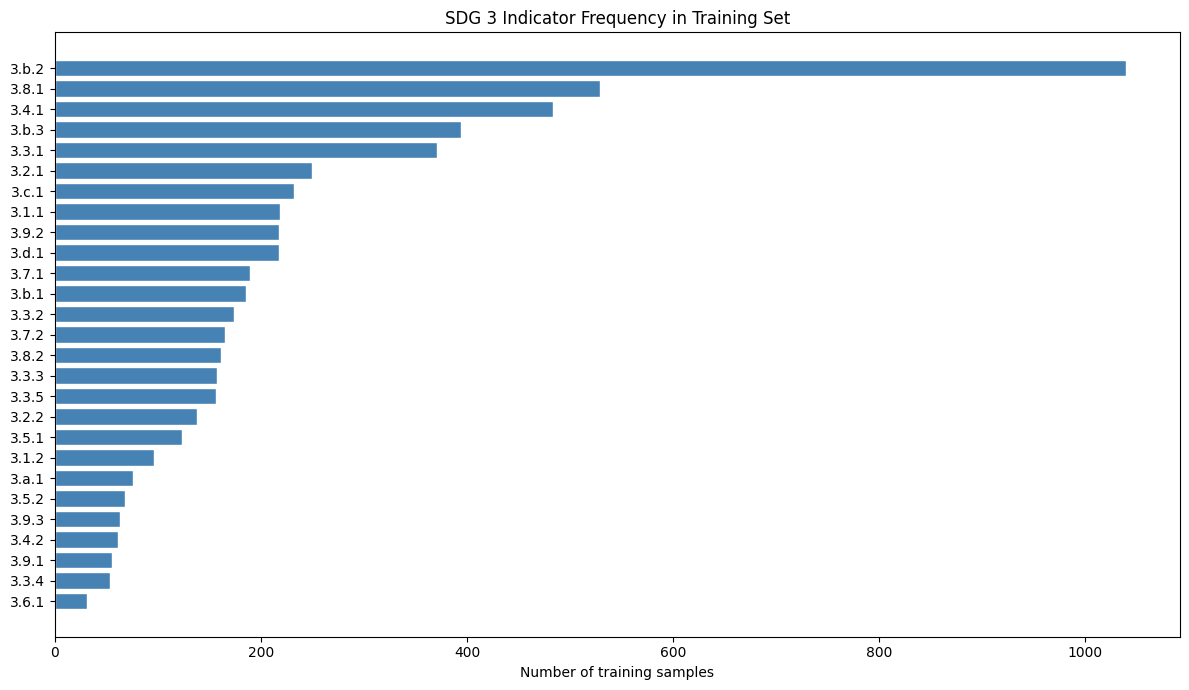

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))
# Shorten labels to the indicator code only (e.g. '3.b.2') for readability.
short_labels = [c.split(' - ')[0] for c in label_freq.index]
ax.barh(short_labels, label_freq.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of training samples')
ax.set_title('SDG 3 Indicator Frequency in Training Set')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'label_frequency.png', dpi=150)
plt.show()

In [18]:
# --- 3.2 Labels per sample distribution ---
# Understanding how many labels each document carries informs the expected
# difficulty: documents with many labels require the model to predict several
# relevant indicators simultaneously.
labels_per_sample = Y.sum(axis=1)
dist = pd.Series(labels_per_sample).value_counts().sort_index()
print('Label count per sample distribution:')
print(dist.to_string())
print()
print(f'Mean labels per sample : {labels_per_sample.mean():.2f}')
print(f'Max labels per sample  : {labels_per_sample.max()}')

Label count per sample distribution:
1     1362
2      905
3      416
4      173
5       81
6       37
7       12
8        5
9        2
10       2

Mean labels per sample : 1.97
Max labels per sample  : 10


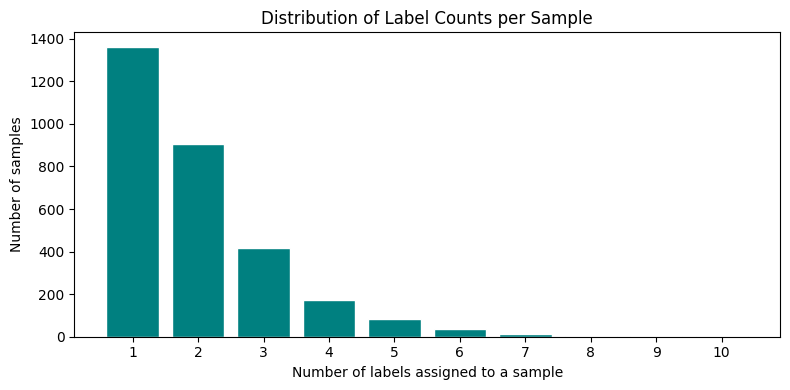

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color='teal', edgecolor='white')
ax.set_xlabel('Number of labels assigned to a sample')
ax.set_ylabel('Number of samples')
ax.set_title('Distribution of Label Counts per Sample')
ax.set_xticks(dist.index)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'labels_per_sample.png', dpi=150)
plt.show()

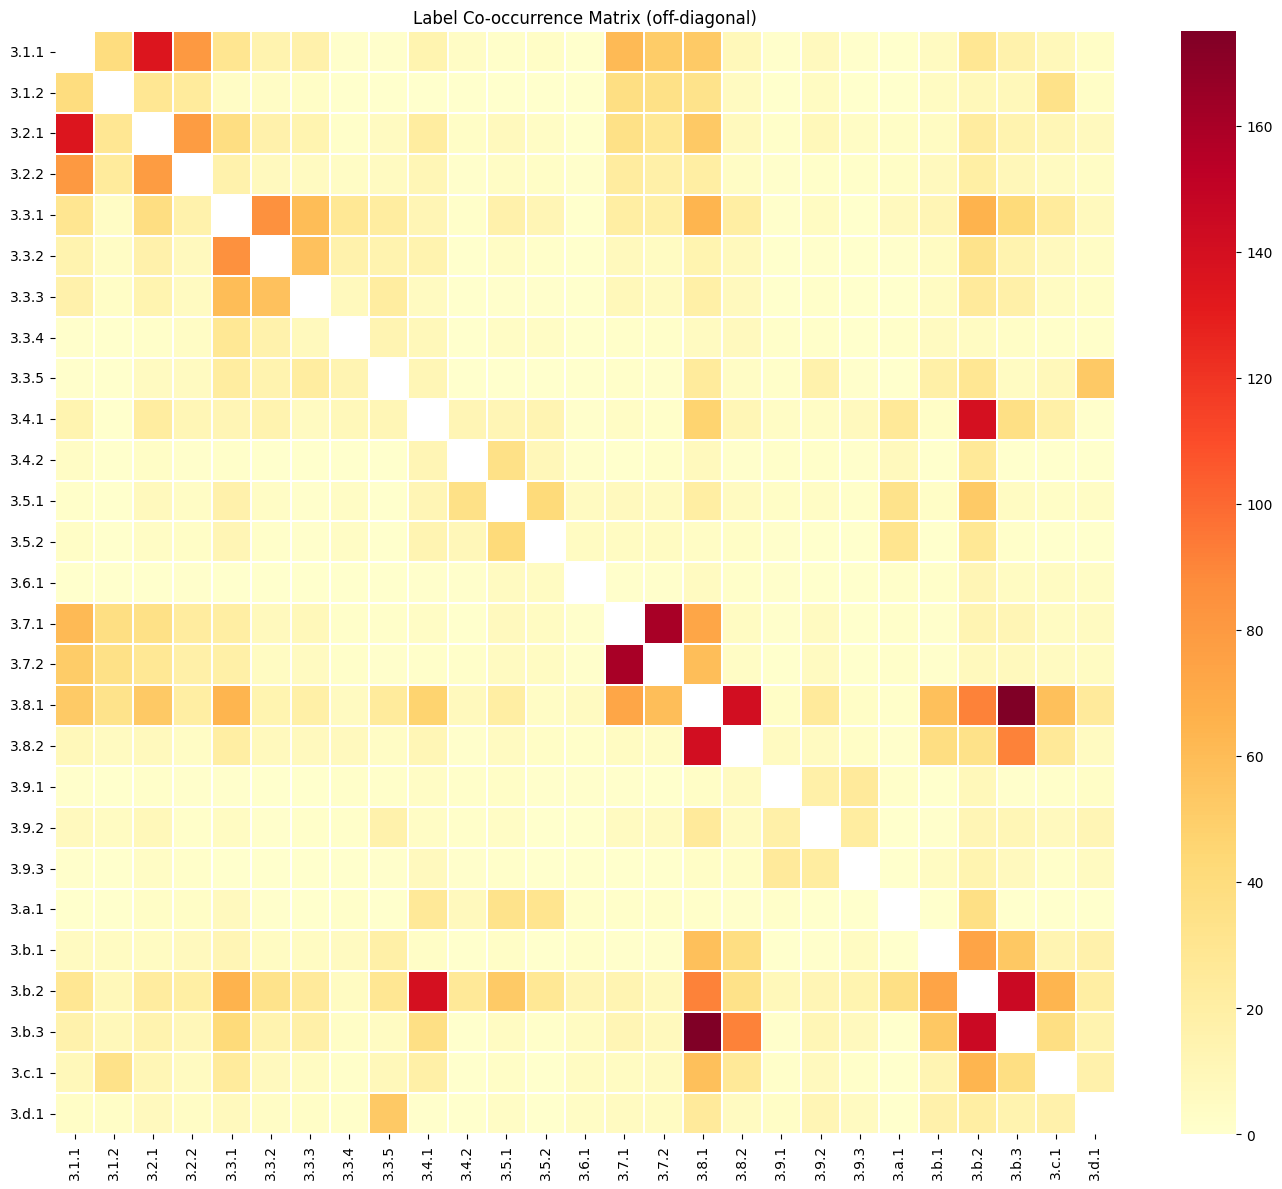

In [20]:
# --- 3.3 Label co-occurrence heatmap ---
# The co-occurrence matrix shows which indicator pairs frequently appear together.
# High co-occurrence suggests that predicting one label should make the other more
# likely — a factor relevant when choosing Classifier Chains over Binary Relevance.
cooccurrence = (Y.T @ Y).astype(int)
short = [c.split(' - ')[0] for c in mlb.classes_]

fig, ax = plt.subplots(figsize=(14, 12))
# Mask the diagonal so the self-count does not dominate the colour scale.
mask = np.eye(len(short), dtype=bool)
sns.heatmap(
    cooccurrence,
    mask=mask,
    xticklabels=short,
    yticklabels=short,
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax
)
ax.set_title('Label Co-occurrence Matrix (off-diagonal)')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'label_cooccurrence.png', dpi=150)
plt.show()

In [21]:
# --- 3.4 Text length statistics ---
# Raw character count of each document.  Very short or very long texts may need
# special handling (truncation for transformer models, minimum-token filters).
train_raw['text_length'] = train_raw['Text'].str.len()

print('Text length statistics:')
print(train_raw['text_length'].describe().to_string())

Text length statistics:
count     2995.000000
mean      3820.610017
std       5245.877776
min         13.000000
25%        131.000000
50%       1670.000000
75%       4794.000000
max      31277.000000


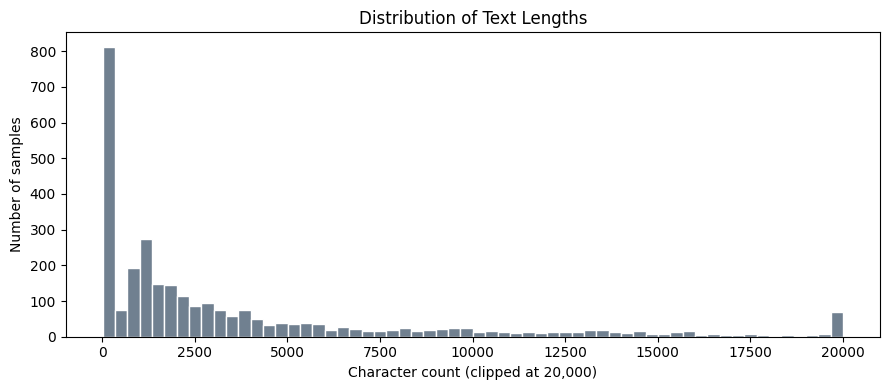

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_raw['text_length'].clip(upper=20000), bins=60, color='slategray', edgecolor='white')
ax.set_xlabel('Character count (clipped at 20,000)')
ax.set_ylabel('Number of samples')
ax.set_title('Distribution of Text Lengths')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'text_length_dist.png', dpi=150)
plt.show()

In [23]:
# --- 3.5 Document type distribution ---
print('Document type counts:')
print(train_raw['Type'].value_counts().to_string())

Document type counts:
Type
Tender          802
Grant           801
Contract        537
Open Opp        229
News            197
Funding Info    193
Organization    154
Program          82


In [24]:
# --- 3.6 Most common tokens (after basic cleaning) ---
# Quick frequency check on raw tokens to identify dominant vocabulary,
# noise tokens (HTML artefacts), and candidate stopwords.
from collections import Counter
from bs4 import BeautifulSoup

def quick_tokenise(text):
    text = BeautifulSoup(str(text), 'lxml').get_text()
    return re.findall(r'\b[a-z]{3,}\b', text.lower())

token_counter = Counter()
for doc in train_raw['Text']:
    token_counter.update(quick_tokenise(doc))

print('Top 40 tokens (before stopword removal):')
for token, count in token_counter.most_common(40):
    print(f'  {count:6d}  {token}')

Top 40 tokens (before stopword removal):
   71039  the
   60962  and
   21268  for
   10472  research
   10268  that
    9689  are
    9504  with
    9150  health
    7475  this
    7329  will
    5195  clinical
    4836  development
    4781  not
    4593  other
    4484  from
    4098  support
    3840  data
    3384  project
    3362  may
    3328  have
    3239  studies
    3203  institutions
    3177  services
    3056  care
    2962  program
    2899  nih
    2768  these
    2740  should
    2618  new
    2614  their
    2570  including
    2534  hiv
    2515  than
    2493  foa
    2451  applications
    2439  information
    2414  use
    2362  which
    2335  based
    2316  has


---
## 4. Preprocessing Pipeline

The preprocessing pipeline is implemented as a set of composable functions.
Each step can be toggled via the configuration dictionary `PREP_CONFIG`, which
makes it easy to run ablation experiments by changing a single flag.

Steps:
1. Strip HTML markup (the raw text contains embedded HTML tags)
2. Lowercase
3. Remove URLs, email addresses, numbers
4. Remove punctuation and excess whitespace
5. Tokenise
6. Remove stopwords (configurable)
7. Lemmatise (configurable)

In [25]:
# Preprocessing configuration.
# To run a variant, copy this dict, change one flag, and pass it to preprocess_text.
PREP_CONFIG = {
    'remove_stopwords': True,
    'lemmatise'       : True,
    'min_token_len'   : 2,
}

STOP_WORDS = set(stopwords.words('english'))
lemmatiser = WordNetLemmatizer()


def strip_html(text: str) -> str:
    """Remove all HTML tags and decode HTML entities."""
    return BeautifulSoup(str(text), 'lxml').get_text(separator=' ')


def clean_text(text: str) -> str:
    """Lowercase, remove URLs, emails, digits, and non-alphabetic characters."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'\S+@\S+', ' ', text)                # email addresses
    text = re.sub(r'\d+', ' ', text)                    # digits
    text = re.sub(r'[^a-z\s]', ' ', text)               # punctuation / symbols
    text = re.sub(r'\s+', ' ', text).strip()            # normalise whitespace
    return text


def tokenise(text: str) -> list:
    """Split text into word tokens using NLTK's word_tokenize."""
    return word_tokenize(text)


def filter_tokens(tokens: list, config: dict) -> list:
    """Apply stopword removal and minimum length filter."""
    min_len = config.get('min_token_len', 2)
    if config.get('remove_stopwords', True):
        tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [t for t in tokens if len(t) >= min_len]
    return tokens


def lemmatise_tokens(tokens: list) -> list:
    """Reduce each token to its base form using WordNet lemmatisation."""
    return [lemmatiser.lemmatize(t) for t in tokens]


def preprocess_text(text: str, config: dict = PREP_CONFIG) -> str:
    """
    Full preprocessing pipeline: HTML stripping -> cleaning -> tokenisation
    -> optional stopword removal -> optional lemmatisation.
    Returns a single whitespace-joined string suitable for vectorisers.
    """
    text = strip_html(text)
    text = clean_text(text)
    tokens = tokenise(text)
    tokens = filter_tokens(tokens, config)
    if config.get('lemmatise', True):
        tokens = lemmatise_tokens(tokens)
    return ' '.join(tokens)


# Quick sanity check on the first training sample.
sample_raw = train_raw.iloc[0]['Text']
sample_clean = preprocess_text(sample_raw)
print('Raw (first 300 chars)  :', sample_raw[:300])
print()
print('Clean (first 300 chars):', sample_clean[:300])

Raw (first 300 chars)  : Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not 

Clean (first 300 chars): center biomedical research excellence cobre phase iii transitional center funding opportunity description institutional development award idea program endeavor stimulate research institution state traditionally received significant level research funding nih created congressional mandate idea progra


In [26]:
# Apply preprocessing to the full training set and the test set.
# tqdm provides a progress bar so you can monitor progress on large corpora.
print('Preprocessing training documents...')
train_texts_clean = [
    preprocess_text(t) for t in tqdm(train_raw['Text'], total=len(train_raw))
]

print('Preprocessing test documents...')
test_texts_clean = [
    preprocess_text(t) for t in tqdm(test_raw['Text'], total=len(test_raw))
]

print(f'Done. {len(train_texts_clean)} train, {len(test_texts_clean)} test documents.')

Preprocessing training documents...


100%|██████████| 2995/2995 [00:45<00:00, 65.52it/s] 


Preprocessing test documents...


100%|██████████| 998/998 [00:04<00:00, 204.76it/s]

Done. 2995 train, 998 test documents.


In [27]:
# Train / validation split.
# We hold out 20 % of training data as a validation set for all experiments.
# stratify is not directly applicable to multi-label targets, so we use a
# simple random split with a fixed seed.
X_train, X_val, Y_train, Y_val = train_test_split(
    train_texts_clean, Y, test_size=0.2, random_state=SEED
)

print(f'Training samples  : {len(X_train)}')
print(f'Validation samples: {len(X_val)}')

Training samples  : 2396
Validation samples: 599


---
## 5. Feature Engineering

We implement five distinct text representation strategies.  Each function returns
a tuple `(X_train_feat, X_val_feat, X_test_feat, vectoriser_or_model)` so that any
experiment can call it and immediately feed the features into a classifier.

| # | Representation | Type |
|---|----------------|------|
| A | Count Vectors (BoW) | Sparse |
| B | TF-IDF unigrams | Sparse |
| C | TF-IDF unigrams + bigrams | Sparse |
| D | GloVe averaged embeddings | Dense |
| E | Sentence-Transformers (MiniLM) | Dense |

In [28]:
# --- A: Bag-of-Words (Count Vectors) ---
# The simplest representation: each document becomes a vector of raw token counts.
# max_features caps vocabulary size to keep memory use tractable.

def get_bow_features(X_tr, X_vl, X_te, max_features=50000):
    vec = CountVectorizer(max_features=max_features, min_df=2)
    Xtr = vec.fit_transform(X_tr)
    Xvl = vec.transform(X_vl)
    Xte = vec.transform(X_te)
    return Xtr, Xvl, Xte, vec


# --- B: TF-IDF unigrams ---
# Weights each token by its term frequency in the document relative to how
# common it is across all documents, reducing the influence of generic words.

def get_tfidf_unigram_features(X_tr, X_vl, X_te, max_features=50000):
    vec = TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=max_features,
        sublinear_tf=True,  # replace tf with 1+log(tf) to dampen very frequent terms
        min_df=2
    )
    Xtr = vec.fit_transform(X_tr)
    Xvl = vec.transform(X_vl)
    Xte = vec.transform(X_te)
    return Xtr, Xvl, Xte, vec


# --- C: TF-IDF unigrams + bigrams ---
# Extends representation B by adding two-word phrases (bigrams), which can
# capture domain-specific collocations such as 'maternal mortality' or
# 'health worker'.

def get_tfidf_bigram_features(X_tr, X_vl, X_te, max_features=80000):
    vec = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=max_features,
        sublinear_tf=True,
        min_df=2
    )
    Xtr = vec.fit_transform(X_tr)
    Xvl = vec.transform(X_vl)
    Xte = vec.transform(X_te)
    return Xtr, Xvl, Xte, vec


print('Feature extraction functions defined: BoW, TF-IDF unigram, TF-IDF bigram.')

Feature extraction functions defined: BoW, TF-IDF unigram, TF-IDF bigram.


In [29]:
# --- D: GloVe averaged document embeddings ---
# Each document is represented as the mean of its token GloVe vectors.
# Tokens not present in the GloVe vocabulary are skipped.
# We use the 100-dimensional GloVe vectors trained on 6B tokens (Wikipedia + Gigaword).
#
# On Colab, download with:
#   !wget -q http://nlp.stanford.edu/data/glove.6B.zip && unzip -q glove.6B.zip
# then set GLOVE_PATH to the extracted file.

GLOVE_PATH = DATA_DIR / 'glove.6B.100d.txt'  # adjust path if needed

def load_glove(path):
    """Load GloVe vectors into a dict mapping token -> numpy array."""
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='Loading GloVe'):
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings


def document_to_glove_vector(text, glove_dict, dim=100):
    """Average the GloVe vectors of all tokens found in the vocabulary."""
    tokens = text.split()
    vecs = [glove_dict[t] for t in tokens if t in glove_dict]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(dim, dtype=np.float32)


def get_glove_features(X_tr, X_vl, X_te, glove_dict, dim=100):
    Xtr = np.array([document_to_glove_vector(t, glove_dict, dim) for t in tqdm(X_tr, desc='Train')])
    Xvl = np.array([document_to_glove_vector(t, glove_dict, dim) for t in tqdm(X_vl, desc='Val')])
    Xte = np.array([document_to_glove_vector(t, glove_dict, dim) for t in tqdm(X_te, desc='Test')])
    return Xtr, Xvl, Xte, glove_dict


# Load GloVe only if the file is present; otherwise skip gracefully.
if GLOVE_PATH.exists():
    glove_dict = load_glove(GLOVE_PATH)
    print(f'Loaded {len(glove_dict):,} GloVe vectors.')
else:
    glove_dict = None
    print('GloVe file not found. Download it and set GLOVE_PATH to enable Experiment 7.')
    print('On Colab: !wget -q http://nlp.stanford.edu/data/glove.6B.zip && unzip -q glove.6B.zip')

GloVe file not found. Download it and set GLOVE_PATH to enable Experiment 7.
On Colab: !wget -q http://nlp.stanford.edu/data/glove.6B.zip && unzip -q glove.6B.zip


In [30]:
# --- E: Sentence-Transformers (all-MiniLM-L6-v2) ---
# Produces a dense 384-dimensional embedding for each document by encoding the
# full sentence/paragraph with a lightweight transformer model.
# We truncate each document to the first 512 tokens because the model has a
# fixed context window and most informative content appears early in the text.

from sentence_transformers import SentenceTransformer

ST_MODEL_NAME = 'all-MiniLM-L6-v2'

def get_sentence_transformer_features(X_tr, X_vl, X_te, model_name=ST_MODEL_NAME,
                                       batch_size=64, max_chars=3000):
    """
    Encode documents with a sentence-transformer model.
    max_chars truncates each document to its first `max_chars` characters before
    encoding to stay within the model's token limit and reduce memory use.
    """
    model = SentenceTransformer(model_name)

    def truncate(texts, max_chars):
        return [t[:max_chars] for t in texts]

    print('Encoding training set...')
    Xtr = model.encode(truncate(X_tr, max_chars), batch_size=batch_size,
                        show_progress_bar=True, convert_to_numpy=True)
    print('Encoding validation set...')
    Xvl = model.encode(truncate(X_vl, max_chars), batch_size=batch_size,
                        show_progress_bar=True, convert_to_numpy=True)
    print('Encoding test set...')
    Xte = model.encode(truncate(X_te, max_chars), batch_size=batch_size,
                        show_progress_bar=True, convert_to_numpy=True)
    return Xtr, Xvl, Xte, model


print('Sentence-Transformer feature function defined.')
print('Note: the model will be downloaded on first use (~80 MB).')

Sentence-Transformer feature function defined.
Note: the model will be downloaded on first use (~80 MB).


---
## 6. Evaluation Utilities

A single `evaluate` function computes all required metrics so every experiment
is scored consistently.  The master results table is accumulated here.

In [31]:
# Master results table — one row per experiment.
results_table = []


def evaluate(Y_true, Y_pred, experiment_name, what_changed, why, notes=''):
    """
    Compute and print evaluation metrics, then append a row to results_table.

    Parameters
    ----------
    Y_true         : binary ground-truth label matrix
    Y_pred         : binary predicted label matrix
    experiment_name: short identifier string
    what_changed   : what was changed vs the previous experiment
    why            : motivation for the change
    notes          : any additional observations
    """
    hl   = hamming_loss(Y_true, Y_pred)
    f1mi = f1_score(Y_true, Y_pred, average='micro', zero_division=0)
    f1ma = f1_score(Y_true, Y_pred, average='macro', zero_division=0)
    prec = precision_score(Y_true, Y_pred, average='micro', zero_division=0)
    rec  = recall_score(Y_true, Y_pred, average='micro', zero_division=0)

    print(f'\n=== {experiment_name} ===')
    print(f'  What changed : {what_changed}')
    print(f'  Why          : {why}')
    print(f'  Hamming Loss : {hl:.4f}  <-- primary metric')
    print(f'  F1 (micro)   : {f1mi:.4f}')
    print(f'  F1 (macro)   : {f1ma:.4f}')
    print(f'  Precision    : {prec:.4f}')
    print(f'  Recall       : {rec:.4f}')
    if notes:
        print(f'  Notes        : {notes}')

    results_table.append({
        'Experiment'   : experiment_name,
        'What Changed' : what_changed,
        'Why'          : why,
        'Hamming Loss' : round(hl, 4),
        'F1 Micro'     : round(f1mi, 4),
        'F1 Macro'     : round(f1ma, 4),
        'Precision'    : round(prec, 4),
        'Recall'       : round(rec, 4),
        'Notes'        : notes,
    })
    return hl


def apply_threshold(Y_prob, threshold=0.5):
    """Convert probability scores to binary predictions using a global threshold."""
    return (Y_prob >= threshold).astype(int)


def per_label_threshold_tuning(Y_prob, Y_true, thresholds=None):
    """
    Find the per-label threshold that minimises Hamming Loss on the validation set.
    Searches over `thresholds` (default 0.1 to 0.9 in steps of 0.05).
    Returns a numpy array of per-label thresholds.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.05)

    n_labels = Y_true.shape[1]
    best_thresholds = np.full(n_labels, 0.5)

    for j in range(n_labels):
        best_hl  = float('inf')
        best_thr = 0.5
        for thr in thresholds:
            y_pred_j = (Y_prob[:, j] >= thr).astype(int)
            # Hamming loss on a single label column
            hl_j = (y_pred_j != Y_true[:, j]).mean()
            if hl_j < best_hl:
                best_hl  = hl_j
                best_thr = thr
        best_thresholds[j] = best_thr

    return best_thresholds


print('Evaluation utilities defined.')

Evaluation utilities defined.


---
## 7. Experiments

Each experiment changes exactly one variable relative to the previous one so its
effect on Hamming Loss is cleanly attributable.  All experiments use the same
80/20 train/validation split and the same random seed.

### Experiment 1 — Baseline: BoW + Logistic Regression (default threshold)

Establishes a lower bound for comparison.  No class-weight correction; default
0.5 prediction threshold; unigram count vectors.

In [32]:
Xtr_bow, Xvl_bow, Xte_bow, vec_bow = get_bow_features(X_train, X_val, test_texts_clean)

# OneVsRestClassifier trains one binary classifier per label.
clf_exp1 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=SEED),
    n_jobs=-1
)
clf_exp1.fit(Xtr_bow, Y_train)

Y_pred_exp1 = clf_exp1.predict(Xvl_bow)

hl1 = evaluate(
    Y_val, Y_pred_exp1,
    experiment_name='Exp 1: BoW + LR (baseline)',
    what_changed='Baseline — no prior experiment',
    why='Establish a reference point using the simplest viable pipeline',
)


=== Exp 1: BoW + LR (baseline) ===
  What changed : Baseline — no prior experiment
  Why          : Establish a reference point using the simplest viable pipeline
  Hamming Loss : 0.0522  <-- primary metric
  F1 (micro)   : 0.5912
  F1 (macro)   : 0.5144
  Precision    : 0.6804
  Recall       : 0.5227


### Experiment 2 — BoW + LR with class_weight='balanced'

The dataset is heavily imbalanced (label frequencies range from 33 to 1,044).
Setting `class_weight='balanced'` instructs the solver to weight rare classes
more heavily, which should improve recall on minority labels.

In [33]:
clf_exp2 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    n_jobs=-1
)
clf_exp2.fit(Xtr_bow, Y_train)

Y_pred_exp2 = clf_exp2.predict(Xvl_bow)

hl2 = evaluate(
    Y_val, Y_pred_exp2,
    experiment_name='Exp 2: BoW + LR + balanced weights',
    what_changed='class_weight changed from None to balanced',
    why='Address label imbalance — rare labels were under-predicted in Exp 1',
)


=== Exp 2: BoW + LR + balanced weights ===
  What changed : class_weight changed from None to balanced
  Why          : Address label imbalance — rare labels were under-predicted in Exp 1
  Hamming Loss : 0.0564  <-- primary metric
  F1 (micro)   : 0.6082
  F1 (macro)   : 0.5394
  Precision    : 0.6109
  Recall       : 0.6056


### Experiment 3 — TF-IDF unigrams + LR

Replace raw counts with TF-IDF weights to down-weight tokens that are common
across all documents and therefore carry little discriminative signal.

In [34]:
Xtr_tfidf1, Xvl_tfidf1, Xte_tfidf1, vec_tfidf1 = get_tfidf_unigram_features(
    X_train, X_val, test_texts_clean
)

clf_exp3 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    n_jobs=-1
)
clf_exp3.fit(Xtr_tfidf1, Y_train)

Y_pred_exp3 = clf_exp3.predict(Xvl_tfidf1)

hl3 = evaluate(
    Y_val, Y_pred_exp3,
    experiment_name='Exp 3: TF-IDF unigram + LR',
    what_changed='Feature representation changed from BoW to TF-IDF unigrams',
    why='TF-IDF suppresses high-frequency generic tokens that add noise to BoW',
)


=== Exp 3: TF-IDF unigram + LR ===
  What changed : Feature representation changed from BoW to TF-IDF unigrams
  Why          : TF-IDF suppresses high-frequency generic tokens that add noise to BoW
  Hamming Loss : 0.0589  <-- primary metric
  F1 (micro)   : 0.6328
  F1 (macro)   : 0.5620
  Precision    : 0.5757
  Recall       : 0.7023


### Experiment 4 — TF-IDF unigrams + bigrams + LR

Add bigrams to capture domain phrases such as 'maternal health', 'health worker',
or 'neglected tropical' that are highly predictive of specific indicators.

In [35]:
Xtr_tfidf2, Xvl_tfidf2, Xte_tfidf2, vec_tfidf2 = get_tfidf_bigram_features(
    X_train, X_val, test_texts_clean
)

clf_exp4 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    n_jobs=-1
)
clf_exp4.fit(Xtr_tfidf2, Y_train)

Y_pred_exp4 = clf_exp4.predict(Xvl_tfidf2)

hl4 = evaluate(
    Y_val, Y_pred_exp4,
    experiment_name='Exp 4: TF-IDF bigram + LR',
    what_changed='ngram_range expanded from (1,1) to (1,2)',
    why='Bigrams encode multi-word medical/health terms not captured by unigrams alone',
)


=== Exp 4: TF-IDF bigram + LR ===
  What changed : ngram_range expanded from (1,1) to (1,2)
  Why          : Bigrams encode multi-word medical/health terms not captured by unigrams alone
  Hamming Loss : 0.0572  <-- primary metric
  F1 (micro)   : 0.6301
  F1 (macro)   : 0.5528
  Precision    : 0.5916
  Recall       : 0.6741


### Experiment 5 — TF-IDF unigrams + Linear SVM

Swap Logistic Regression for LinearSVC.  SVMs with a linear kernel are frequently
the best-performing sparse text classifiers because they find the maximum-margin
hyperplane directly rather than optimising a log-likelihood.

In [36]:
# LinearSVC does not natively output probabilities, so we wrap it with
# CalibratedClassifierCV to obtain probability estimates for threshold tuning.
from sklearn.calibration import CalibratedClassifierCV

base_svm = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED),
    cv=3
)
clf_exp5 = OneVsRestClassifier(base_svm, n_jobs=-1)
clf_exp5.fit(Xtr_tfidf1, Y_train)

Y_pred_exp5 = clf_exp5.predict(Xvl_tfidf1)

hl5 = evaluate(
    Y_val, Y_pred_exp5,
    experiment_name='Exp 5: TF-IDF unigram + LinearSVC',
    what_changed='Classifier changed from Logistic Regression to LinearSVC',
    why='SVMs often outperform LR on sparse high-dimensional text features',
)


=== Exp 5: TF-IDF unigram + LinearSVC ===
  What changed : Classifier changed from Logistic Regression to LinearSVC
  Why          : SVMs often outperform LR on sparse high-dimensional text features
  Hamming Loss : 0.0454  <-- primary metric
  F1 (micro)   : 0.6108
  F1 (macro)   : 0.5251
  Precision    : 0.8033
  Recall       : 0.4927


### Experiment 6 — TF-IDF unigrams + LR + per-label threshold tuning

The default 0.5 threshold is suboptimal for imbalanced labels: rare labels need
a lower threshold (predict positive more aggressively) while dominant labels may
need a higher one.  We tune a separate threshold per label on the validation set.

In [37]:
# Obtain probability estimates from Exp 3's LR model.
Y_prob_exp6 = clf_exp3.predict_proba(Xvl_tfidf1)

# Find per-label thresholds that minimise Hamming Loss on the validation set.
best_thresholds = per_label_threshold_tuning(Y_prob_exp6, Y_val)

# Apply the tuned thresholds.
Y_pred_exp6 = np.zeros_like(Y_prob_exp6, dtype=int)
for j, thr in enumerate(best_thresholds):
    Y_pred_exp6[:, j] = (Y_prob_exp6[:, j] >= thr).astype(int)

hl6 = evaluate(
    Y_val, Y_pred_exp6,
    experiment_name='Exp 6: TF-IDF unigram + LR + per-label thresholds',
    what_changed='Prediction threshold changed from global 0.5 to per-label tuned values',
    why='Global threshold is suboptimal when label frequencies vary by 32x',
    notes=f'Threshold range: {best_thresholds.min():.2f} – {best_thresholds.max():.2f}',
)


=== Exp 6: TF-IDF unigram + LR + per-label thresholds ===
  What changed : Prediction threshold changed from global 0.5 to per-label tuned values
  Why          : Global threshold is suboptimal when label frequencies vary by 32x
  Hamming Loss : 0.0435  <-- primary metric
  F1 (micro)   : 0.6542
  F1 (macro)   : 0.5617
  Precision    : 0.7682
  Recall       : 0.5697
  Notes        : Threshold range: 0.40 – 0.90


In [38]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip && unzip -q glove.6B.zip -d /content/data

### Experiment 7 — GloVe embeddings + LR

Move from sparse bag-of-words to dense pre-trained word vectors.  GloVe captures
semantic similarity between words (e.g. 'malaria' and 'dengue' are close in
embedding space), which TF-IDF cannot represent.

In [39]:
if glove_dict is not None:
    Xtr_glove, Xvl_glove, Xte_glove, _ = get_glove_features(
        X_train, X_val, test_texts_clean, glove_dict
    )

    clf_exp7 = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        n_jobs=-1
    )
    clf_exp7.fit(Xtr_glove, Y_train)

    Y_pred_exp7 = clf_exp7.predict(Xvl_glove)

    hl7 = evaluate(
        Y_val, Y_pred_exp7,
        experiment_name='Exp 7: GloVe averaged + LR',
        what_changed='Feature representation changed from sparse TF-IDF to dense GloVe mean vectors',
        why='Dense embeddings encode semantic relationships not visible in sparse counts',
    )
else:
    print('Skipping Exp 7: GloVe file not available. Download and re-run.')

Skipping Exp 7: GloVe file not available. Download and re-run.


### Experiment 8 — Sentence-Transformers (all-MiniLM-L6-v2) + LR

Replace averaged GloVe with a modern sentence encoder.  Unlike averaged word
vectors, sentence-transformer embeddings are computed over the full sequence
and are sensitive to word order and context.

In [40]:
Xtr_st, Xvl_st, Xte_st, st_model = get_sentence_transformer_features(
    X_train, X_val, test_texts_clean
)

clf_exp8 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    n_jobs=-1
)
clf_exp8.fit(Xtr_st, Y_train)

Y_pred_exp8 = clf_exp8.predict(Xvl_st)

hl8 = evaluate(
    Y_val, Y_pred_exp8,
    experiment_name='Exp 8: Sentence-Transformer + LR',
    what_changed='Embedding changed from GloVe averages to sentence-transformer (MiniLM-L6-v2)',
    why='Contextual sentence embeddings should outperform averaged word vectors for long documents',
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding validation set...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


=== Exp 8: Sentence-Transformer + LR ===
  What changed : Embedding changed from GloVe averages to sentence-transformer (MiniLM-L6-v2)
  Why          : Contextual sentence embeddings should outperform averaged word vectors for long documents
  Hamming Loss : 0.0960  <-- primary metric
  F1 (micro)   : 0.5466
  F1 (macro)   : 0.4945
  Precision    : 0.4149
  Recall       : 0.8007


### Experiment 9 — Sentence-Transformers + LinearSVC

Repeat the best sparse-features pattern (SVM) with the best dense features
(sentence transformer) to test whether the classifier choice that helped on
sparse features also helps on dense ones.

In [41]:
base_svm2 = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED),
    cv=3
)
clf_exp9 = OneVsRestClassifier(base_svm2, n_jobs=-1)
clf_exp9.fit(Xtr_st, Y_train)

Y_pred_exp9 = clf_exp9.predict(Xvl_st)

hl9 = evaluate(
    Y_val, Y_pred_exp9,
    experiment_name='Exp 9: Sentence-Transformer + LinearSVC',
    what_changed='Classifier changed from LR to LinearSVC (same sentence-transformer features)',
    why='Verify whether SVM advantage observed on sparse features transfers to dense embeddings',
)


=== Exp 9: Sentence-Transformer + LinearSVC ===
  What changed : Classifier changed from LR to LinearSVC (same sentence-transformer features)
  Why          : Verify whether SVM advantage observed on sparse features transfers to dense embeddings
  Hamming Loss : 0.0475  <-- primary metric
  F1 (micro)   : 0.5780
  F1 (macro)   : 0.4471
  Precision    : 0.8080
  Recall       : 0.4500


### Experiment 10 — Best model + per-label threshold tuning

Apply per-label threshold tuning to the best-performing model from Experiments
8 and 9, combining the strongest embedding with calibrated decision boundaries.

In [42]:
# Use the model that achieved the lower Hamming Loss among Exp 8 and Exp 9.
best_dense_clf = clf_exp8 if hl8 <= hl9 else clf_exp9
best_dense_name = 'Exp 8 (ST + LR)' if hl8 <= hl9 else 'Exp 9 (ST + SVM)'
print(f'Using {best_dense_name} as base for Exp 10.')

Y_prob_exp10 = best_dense_clf.predict_proba(Xvl_st)

best_thresholds_exp10 = per_label_threshold_tuning(Y_prob_exp10, Y_val)

Y_pred_exp10 = np.zeros_like(Y_prob_exp10, dtype=int)
for j, thr in enumerate(best_thresholds_exp10):
    Y_pred_exp10[:, j] = (Y_prob_exp10[:, j] >= thr).astype(int)

hl10 = evaluate(
    Y_val, Y_pred_exp10,
    experiment_name='Exp 10: Best dense model + per-label thresholds',
    what_changed=f'Added per-label threshold tuning on top of {best_dense_name}',
    why='Threshold tuning improved Exp 6 over Exp 3; testing whether it helps on the best dense model too',
    notes=f'Threshold range: {best_thresholds_exp10.min():.2f} – {best_thresholds_exp10.max():.2f}',
)

Using Exp 9 (ST + SVM) as base for Exp 10.

=== Exp 10: Best dense model + per-label thresholds ===
  What changed : Added per-label threshold tuning on top of Exp 9 (ST + SVM)
  Why          : Threshold tuning improved Exp 6 over Exp 3; testing whether it helps on the best dense model too
  Hamming Loss : 0.0430  <-- primary metric
  F1 (micro)   : 0.6423
  F1 (macro)   : 0.5788
  Precision    : 0.8044
  Recall       : 0.5346
  Notes        : Threshold range: 0.20 – 0.70


---
## 8. Results Comparison

Compile all experiment results into a single table and produce visualisations
to highlight which changes had the greatest impact on Hamming Loss.

In [43]:
df_results = pd.DataFrame(results_table)
df_results = df_results.sort_values('Hamming Loss').reset_index(drop=True)

print('Master results table (sorted by Hamming Loss ascending):')
display_cols = ['Experiment', 'Hamming Loss', 'F1 Micro', 'F1 Macro', 'Precision', 'Recall']
print(df_results[display_cols].to_string(index=False))

# Save to CSV for inclusion in the report.
df_results.to_csv(ARTIFACTS_DIR / 'experiment_results.csv', index=False)
print('\nSaved to artifacts/experiment_results.csv')

Master results table (sorted by Hamming Loss ascending):
                                       Experiment  Hamming Loss  F1 Micro  F1 Macro  Precision  Recall
  Exp 10: Best dense model + per-label thresholds        0.0430    0.6423    0.5788     0.8044  0.5346
Exp 6: TF-IDF unigram + LR + per-label thresholds        0.0435    0.6542    0.5617     0.7682  0.5697
                Exp 5: TF-IDF unigram + LinearSVC        0.0454    0.6108    0.5251     0.8033  0.4927
          Exp 9: Sentence-Transformer + LinearSVC        0.0475    0.5780    0.4471     0.8080  0.4500
                       Exp 1: BoW + LR (baseline)        0.0522    0.5912    0.5144     0.6804  0.5227
               Exp 2: BoW + LR + balanced weights        0.0564    0.6082    0.5394     0.6109  0.6056
                        Exp 4: TF-IDF bigram + LR        0.0572    0.6301    0.5528     0.5916  0.6741
                       Exp 3: TF-IDF unigram + LR        0.0589    0.6328    0.5620     0.5757  0.7023
                

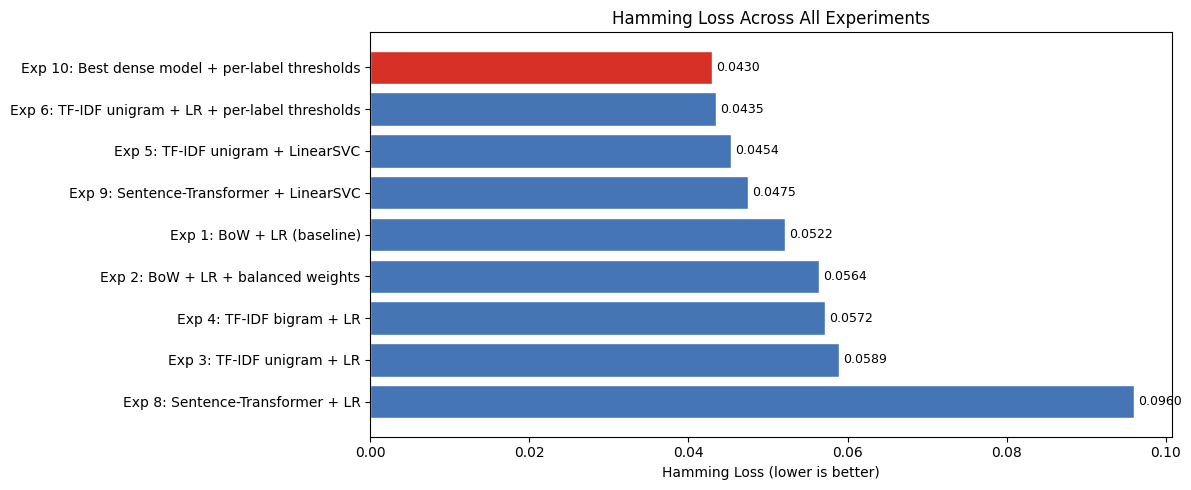

In [44]:
# Hamming Loss comparison bar chart.
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d73027' if v == df_results['Hamming Loss'].min() else '#4575b4'
          for v in df_results['Hamming Loss']]
ax.barh(df_results['Experiment'], df_results['Hamming Loss'],
        color=colors, edgecolor='white')
ax.set_xlabel('Hamming Loss (lower is better)')
ax.set_title('Hamming Loss Across All Experiments')
ax.invert_yaxis()
for i, (val, name) in enumerate(zip(df_results['Hamming Loss'], df_results['Experiment'])):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'hamming_loss_comparison.png', dpi=150)
plt.show()

### Learning Curve

A learning curve plots validation Hamming Loss as a function of training set size.
It reveals whether the best model is data-hungry (performance still improving at full
training size, suggesting more data would help) or has plateaued (suggesting the model
has reached its capacity on this data).

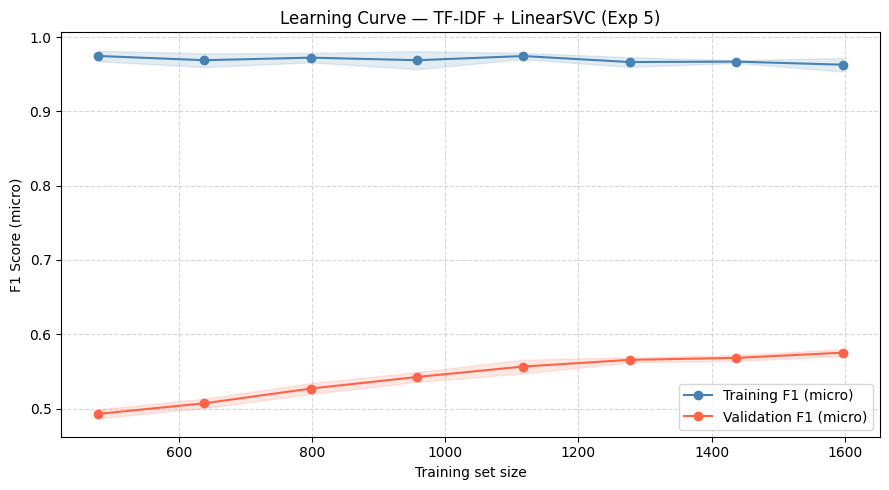

Final validation F1 at full training size: 0.5752


In [45]:
# Learning curve for the best model using TF-IDF + LinearSVC (Exp 5).
# We use TF-IDF + SVM rather than the sentence-transformer because re-encoding
# at each subset size would be prohibitively slow.  The curve still illustrates
# the data-scaling behaviour of the classifier family.
from sklearn.model_selection import learning_curve

train_sizes_frac = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# learning_curve expects a single estimator; we refit on TF-IDF features.
lc_clf = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED), cv=3
    ),
    n_jobs=-1
)

train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_clf,
    Xtr_tfidf1,
    Y_train,
    train_sizes=train_sizes_frac,
    cv=3,
    scoring='f1_micro',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Training F1 (micro)')
ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes_abs, val_mean, 'o-', color='tomato', label='Validation F1 (micro)')
ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
ax.set_xlabel('Training set size')
ax.set_ylabel('F1 Score (micro)')
ax.set_title('Learning Curve — TF-IDF + LinearSVC (Exp 5)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'learning_curve.png', dpi=150)
plt.show()

print(f'Final validation F1 at full training size: {val_mean[-1]:.4f}')

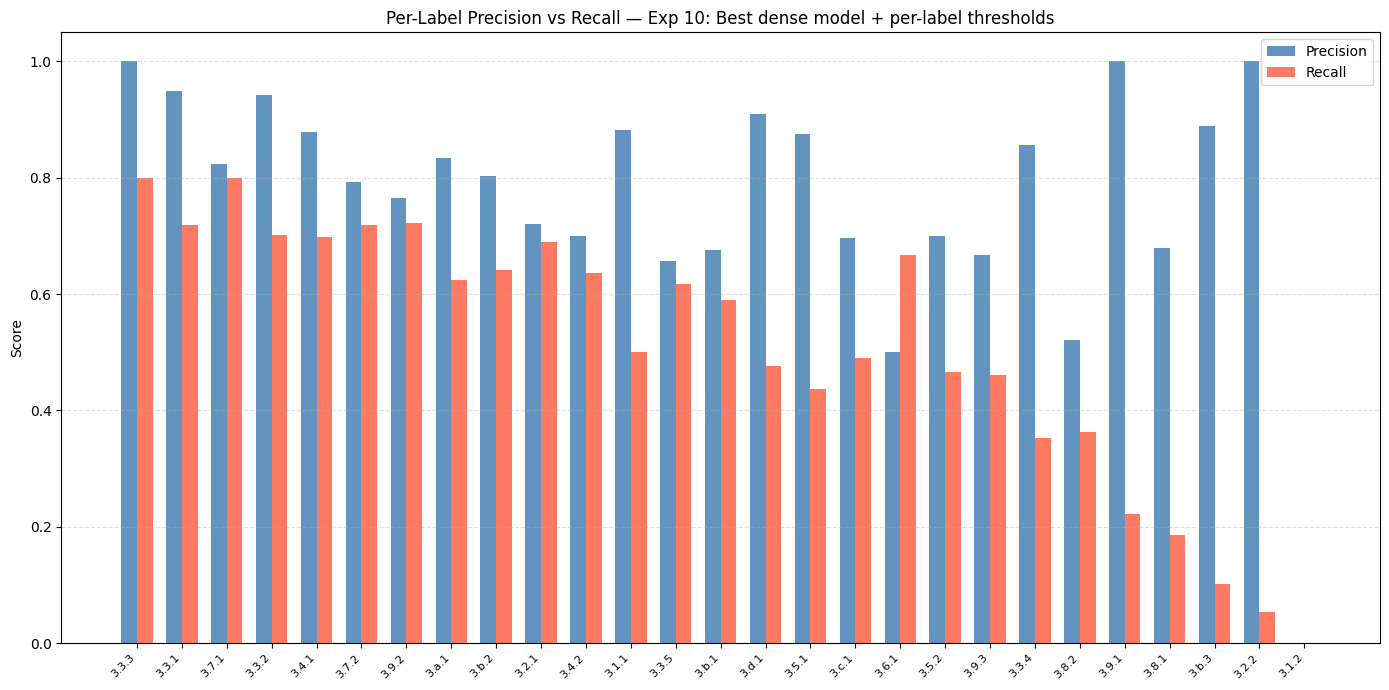

Indicator  Precision   Recall       F1  Support
    3.3.3   1.000000 0.800000 0.888889       45
    3.3.1   0.949153 0.717949 0.817518       78
    3.7.1   0.823529 0.800000 0.811594       35
    3.3.2   0.942857 0.702128 0.804878       47
    3.4.1   0.878378 0.698925 0.778443       93
    3.7.2   0.793103 0.718750 0.754098       32
    3.9.2   0.764706 0.722222 0.742857       36
    3.a.1   0.833333 0.625000 0.714286       16
    3.b.2   0.802326 0.641860 0.713178      215
    3.2.1   0.720930 0.688889 0.704545       45
    3.4.2   0.700000 0.636364 0.666667       11
    3.1.1   0.882353 0.500000 0.638298       30
    3.3.5   0.656250 0.617647 0.636364       34
    3.b.1   0.676471 0.589744 0.630137       39
    3.d.1   0.909091 0.476190 0.625000       42
    3.5.1   0.875000 0.437500 0.583333       16
    3.c.1   0.696970 0.489362 0.575000       47
    3.6.1   0.500000 0.666667 0.571429        3
    3.5.2   0.700000 0.466667 0.560000       15
    3.9.3   0.666667 0.461538 0.545455  

In [49]:
# Per-label precision, recall, and F1 breakdown for the best model.
# This replaces a confusion matrix (which is not directly applicable to multi-label
# problems) with a per-indicator breakdown showing where the model is
# precise, where it over-predicts (high recall, low precision), and where
# it under-predicts (low recall, high precision).

if Y_best is not None:
    per_label_prec = precision_score(Y_val, Y_best, average=None, zero_division=0)
    per_label_rec  = recall_score(Y_val, Y_best, average=None, zero_division=0)
    per_label_f1s  = f1_score(Y_val, Y_best, average=None, zero_division=0)
    short          = [c.split(' - ')[0] for c in mlb.classes_]

    df_breakdown = pd.DataFrame({
        'Indicator' : short,
        'Precision' : per_label_prec,
        'Recall'    : per_label_rec,
        'F1'        : per_label_f1s,
        'Support'   : Y_val.sum(axis=0),
    }).sort_values('F1', ascending=False).reset_index(drop=True)

    # Grouped bar chart: precision and recall side by side per indicator.
    x      = np.arange(len(short))
    width  = 0.35
    sorted_idx = df_breakdown.index  # already sorted by F1

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.bar(x - width/2, df_breakdown['Precision'], width, label='Precision', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, df_breakdown['Recall'],    width, label='Recall',    color='tomato',    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df_breakdown['Indicator'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    ax.set_title(f'Per-Label Precision vs Recall — {best_exp_name}')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'per_label_precision_recall.png', dpi=150)
    plt.show()

    print(df_breakdown.to_string(index=False))
    df_breakdown.to_csv(ARTIFACTS_DIR / 'per_label_breakdown.csv', index=False)
    print('\nSaved to artifacts/per_label_breakdown.csv')

Computing per-label F1 for best experiment: Exp 10: Best dense model + per-label thresholds


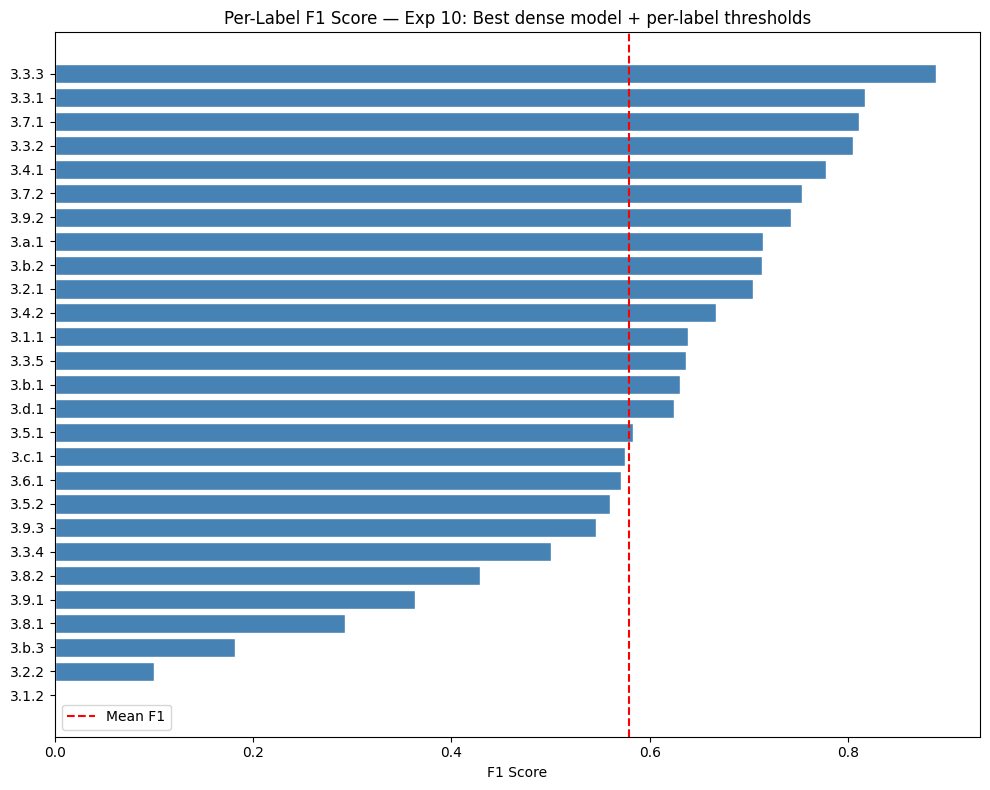

Indicator       F1
    3.3.3 0.888889
    3.3.1 0.817518
    3.7.1 0.811594
    3.3.2 0.804878
    3.4.1 0.778443
    3.7.2 0.754098
    3.9.2 0.742857
    3.a.1 0.714286
    3.b.2 0.713178
    3.2.1 0.704545
    3.4.2 0.666667
    3.1.1 0.638298
    3.3.5 0.636364
    3.b.1 0.630137
    3.d.1 0.625000
    3.5.1 0.583333
    3.c.1 0.575000
    3.6.1 0.571429
    3.5.2 0.560000
    3.9.3 0.545455
    3.3.4 0.500000
    3.8.2 0.428571
    3.9.1 0.363636
    3.8.1 0.292308
    3.b.3 0.181818
    3.2.2 0.100000
    3.1.2 0.000000


In [48]:
# Per-label F1 score for the best model.
# Identifies which indicators the model handles well and which need attention.
best_exp_name = df_results.iloc[0]['Experiment']
print(f'Computing per-label F1 for best experiment: {best_exp_name}')

# Map experiment name to its predictions.
pred_map = {
    'Exp 1: BoW + LR (baseline)'                       : Y_pred_exp1,
    'Exp 2: BoW + LR + balanced weights'                : Y_pred_exp2,
    'Exp 3: TF-IDF unigram + LR'                        : Y_pred_exp3,
    'Exp 4: TF-IDF bigram + LR'                         : Y_pred_exp4,
    'Exp 5: TF-IDF unigram + LinearSVC'                 : Y_pred_exp5,
    'Exp 6: TF-IDF unigram + LR + per-label thresholds' : Y_pred_exp6,
    'Exp 8: Sentence-Transformer + LR'                  : Y_pred_exp8,
    'Exp 9: Sentence-Transformer + LinearSVC'           : Y_pred_exp9,
    'Exp 10: Best dense model + per-label thresholds'   : Y_pred_exp10,
}

# Include Exp 7 only if GloVe was available and the experiment ran.
if glove_dict is not None and 'hl7' in dir():
    pred_map['Exp 7: GloVe averaged + LR'] = Y_pred_exp7

Y_best = pred_map.get(best_exp_name)
if Y_best is not None:
    per_label_f1 = f1_score(Y_val, Y_best, average=None, zero_division=0)
    short_labels  = [c.split(' - ')[0] for c in mlb.classes_]
    df_per_label  = pd.DataFrame({'Indicator': short_labels, 'F1': per_label_f1})
    df_per_label  = df_per_label.sort_values('F1', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(df_per_label['Indicator'], df_per_label['F1'],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('F1 Score')
    ax.set_title(f'Per-Label F1 Score — {best_exp_name}')
    ax.invert_yaxis()
    ax.axvline(x=per_label_f1.mean(), color='red', linestyle='--', label='Mean F1')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'per_label_f1_best_model.png', dpi=150)
    plt.show()

    print(df_per_label.to_string(index=False))

---
## 9. Save Best Model Artifacts

In [50]:
# Identify and persist the best model and its associated vectoriser/encoder.
# We save: the classifier, the label binarizer, and the preprocessing config
# so that inference can be reproduced without this notebook.

best_clf_obj = pred_map.get(best_exp_name)  # predictions

# Map experiment name to (classifier, feature_matrix_for_test) for saving.
clf_map = {
    'Exp 1: BoW + LR (baseline)'                    : (clf_exp1, Xte_bow,    vec_bow),
    'Exp 2: BoW + LR + balanced weights'             : (clf_exp2, Xte_bow,    vec_bow),
    'Exp 3: TF-IDF unigram + LR'                     : (clf_exp3, Xte_tfidf1, vec_tfidf1),
    'Exp 4: TF-IDF bigram + LR'                      : (clf_exp4, Xte_tfidf2, vec_tfidf2),
    'Exp 5: TF-IDF unigram + LinearSVC'              : (clf_exp5, Xte_tfidf1, vec_tfidf1),
    'Exp 6: TF-IDF unigram + LR + per-label thresholds': (clf_exp3, Xte_tfidf1, vec_tfidf1),
    'Exp 8: Sentence-Transformer + LR'               : (clf_exp8, Xte_st,     st_model),
    'Exp 9: Sentence-Transformer + LinearSVC'        : (clf_exp9, Xte_st,     st_model),
    'Exp 10: Best dense model + per-label thresholds': (best_dense_clf, Xte_st, st_model),
}

best_clf, best_Xte, best_vec = clf_map[best_exp_name]

joblib.dump(best_clf,       ARTIFACTS_DIR / 'best_classifier.joblib')
joblib.dump(mlb,            ARTIFACTS_DIR / 'label_binarizer.joblib')
joblib.dump(PREP_CONFIG,    ARTIFACTS_DIR / 'prep_config.joblib')

# Save the vectoriser only for sparse-feature models (sentence-transformer
# models are saved as a directory by SentenceTransformer itself).
if hasattr(best_vec, 'vocabulary_'):
    joblib.dump(best_vec, ARTIFACTS_DIR / 'vectoriser.joblib')

print('Saved artifacts:')
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(' ', p.name)

Saved artifacts:
  best_classifier.joblib
  experiment_results.csv
  hamming_loss_comparison.png
  label_binarizer.joblib
  label_cooccurrence.png
  label_frequency.png
  labels_per_sample.png
  learning_curve.png
  per_label_breakdown.csv
  per_label_f1_best_model.png
  per_label_precision_recall.png
  prep_config.joblib
  text_length_dist.png


---
## 10. Inference on the Test Set

Apply the best model to `Devex_test_questions.csv` and produce a predictions
file in the same wide-string label format as the training targets.

In [51]:
# Generate binary predictions for the test set using the best model.
# For threshold-tuned experiments we apply the tuned thresholds;
# otherwise we use the model's default decision boundary.

if 'per-label thresholds' in best_exp_name:
    Y_prob_test = best_clf.predict_proba(best_Xte)
    Y_pred_test = np.zeros_like(Y_prob_test, dtype=int)
    thresholds_to_use = (
        best_thresholds_exp10
        if 'Exp 10' in best_exp_name
        else best_thresholds
    )
    for j, thr in enumerate(thresholds_to_use):
        Y_pred_test[:, j] = (Y_prob_test[:, j] >= thr).astype(int)
else:
    Y_pred_test = best_clf.predict(best_Xte)

print('Test prediction shape:', Y_pred_test.shape)

Test prediction shape: (998, 27)


In [52]:
# Convert the binary prediction matrix back to the wide-string label format
# that matches the training file schema (Label 1, Label 2, ... Label 10).

def binary_to_wide_labels(Y_bin, classes, max_label_cols=10):
    """
    Convert a binary label matrix back to a wide-format DataFrame with columns
    'Label 1' through 'Label N', where each cell contains an indicator string
    or NaN — mirroring the training file format.
    """
    rows = []
    for row in Y_bin:
        active = [classes[i] for i, v in enumerate(row) if v == 1]
        padded = active[:max_label_cols] + [np.nan] * (max_label_cols - len(active))
        rows.append(padded)
    cols = [f'Label {i+1}' for i in range(max_label_cols)]
    return pd.DataFrame(rows, columns=cols)


label_df = binary_to_wide_labels(Y_pred_test, mlb.classes_)

# Combine with the test set identifiers.
predictions_df = pd.concat(
    [test_raw[['Unique ID', 'Type']].reset_index(drop=True), label_df],
    axis=1
)

output_path = ARTIFACTS_DIR / 'test_predictions.csv'
predictions_df.to_csv(output_path, index=False)

print(f'Predictions saved to {output_path}')
print(f'Shape: {predictions_df.shape}')
print()
print('First 3 prediction rows:')
print(predictions_df.head(3).to_string())

Predictions saved to /content/artifacts/test_predictions.csv
Shape: (998, 12)

First 3 prediction rows:
   Unique ID          Type                                                                                                                                   Label 1                                                                                                                                                                                                                                                                                                                                     Label 2                                                                                                                           Label 3 Label 4 Label 5  Label 6  Label 7  Label 8  Label 9  Label 10
0      49848  Organization  3.7.1 - Proportion of women of reproductive age (aged 15_49 years) who have their need for family planning satisfied with modern methods  3.8.1 - Coverage of essential health serv

In [53]:
# Summary of label distribution in the test predictions.
# Comparing this to the training label distribution is a useful sanity check:
# the proportions should be broadly similar if the test set is from the same
# distribution.
test_label_counts = Y_pred_test.sum(axis=0)
test_label_series = pd.Series(test_label_counts, index=mlb.classes_).sort_values(ascending=False)

print('Predicted label counts on test set:')
for ind, cnt in test_label_series.items():
    print(f'  {cnt:4d}  {ind.split(" - ")[0]}')

Predicted label counts on test set:
   284  3.b.2
   120  3.4.1
   105  3.3.1
    78  3.2.1
    63  3.b.1
    57  3.9.2
    53  3.7.1
    48  3.3.3
    46  3.3.5
    43  3.7.2
    42  3.c.1
    38  3.8.1
    37  3.3.2
    37  3.1.1
    35  3.a.1
    34  3.5.2
    29  3.d.1
    23  3.8.2
    23  3.4.2
    20  3.5.1
    19  3.3.4
    13  3.9.3
    13  3.b.3
     9  3.2.2
     4  3.1.2
     3  3.6.1
     1  3.9.1


---
## 11. Final Summary

The cell below prints a concise end-to-end summary for inclusion in the report.

In [54]:
print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'Training samples  : {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples      : {len(test_texts_clean)}')
print(f'Unique indicators : {len(mlb.classes_)}')
print(f'Total experiments : {len(results_table)}')
print()
print('Best experiment    :', best_exp_name)
print('Best Hamming Loss  :', df_results.iloc[0]['Hamming Loss'])
print('Best F1 (micro)    :', df_results.iloc[0]['F1 Micro'])
print()
print('All results (Hamming Loss ascending):')
print(df_results[['Experiment', 'Hamming Loss', 'F1 Micro']].to_string(index=False))

PIPELINE SUMMARY
Training samples  : 2396
Validation samples: 599
Test samples      : 998
Unique indicators : 27
Total experiments : 9

Best experiment    : Exp 10: Best dense model + per-label thresholds
Best Hamming Loss  : 0.043
Best F1 (micro)    : 0.6423

All results (Hamming Loss ascending):
                                       Experiment  Hamming Loss  F1 Micro
  Exp 10: Best dense model + per-label thresholds        0.0430    0.6423
Exp 6: TF-IDF unigram + LR + per-label thresholds        0.0435    0.6542
                Exp 5: TF-IDF unigram + LinearSVC        0.0454    0.6108
          Exp 9: Sentence-Transformer + LinearSVC        0.0475    0.5780
                       Exp 1: BoW + LR (baseline)        0.0522    0.5912
               Exp 2: BoW + LR + balanced weights        0.0564    0.6082
                        Exp 4: TF-IDF bigram + LR        0.0572    0.6301
                       Exp 3: TF-IDF unigram + LR        0.0589    0.6328
                 Exp 8: Sentence-Tr